In [1]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands, Graphs
import pandas as pd
train_info = GraphsTraining()

### Load JAX

In [2]:
results_reg_jax = load_all_pickles("results/jax_vdp_net_size", recursive=True)
results_df_jax = Results.flatten_convergence_data(results_reg_jax, model_type="pytorch")

Loaded results/jax_vdp_net_size/jax_vdp_w2-32-2_1000_10000_160226_1403/1407726570_2026-02-16_14-05.pkl
Loaded results/jax_vdp_net_size/jax_vdp_w2-32-2_1000_10000_160226_1403/1457972169_2026-02-16_14-11.pkl
Loaded results/jax_vdp_net_size/jax_vdp_w2-32-2_1000_10000_160226_1403/1846716783_2026-02-16_14-16.pkl
Loaded results/jax_vdp_net_size/jax_vdp_w2-32-2_1000_10000_160226_1403/2202375916_2026-02-16_14-18.pkl
Loaded results/jax_vdp_net_size/jax_vdp_w2-32-2_1000_10000_160226_1403/2362737496_2026-02-16_14-20.pkl
Loaded results/jax_vdp_net_size/jax_vdp_w2-32-2_1000_10000_160226_1403/2396454905_2026-02-16_14-26.pkl
Loaded results/jax_vdp_net_size/jax_vdp_w2-32-2_1000_10000_160226_1403/2419678567_2026-02-16_14-32.pkl
Loaded results/jax_vdp_net_size/jax_vdp_w2-32-2_1000_10000_160226_1403/2429260521_2026-02-16_14-30.pkl
Loaded results/jax_vdp_net_size/jax_vdp_w2-32-2_1000_10000_160226_1403/2489209324_2026-02-16_14-15.pkl
Loaded results/jax_vdp_net_size/jax_vdp_w2-32-2_1000_10000_160226_1403/28

### Load Pyomo

In [3]:
results_reg_norm = load_all_pickles("results/pyomo_vdp_net_size_no_reg_norm", recursive=False)
results_reg_norm_df = Results.flatten_convergence_data(results_reg_norm, key_list=["system", "reg", "tol"], model_type="pyomo")

results_reg_norm_df = results_reg_norm_df.dropna()
results_reg_norm_df["n_neurons"] = results_reg_norm_df["system"].apply(lambda x: x[1])

Loaded results/pyomo_vdp_net_size_no_reg_norm/2481537476_2026-02-15_14-15.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/2602659206_2026-02-15_13-37.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/2615588203_2026-02-15_13-12.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/2897332925_2026-02-15_13-49.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/3028133238_2026-02-15_13-02.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/3269951338_2026-02-15_12-41.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/33713814_2026-02-15_14-43.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/3488423091_2026-02-15_14-58.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/3824352641_2026-02-15_13-25.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/3952110356_2026-02-15_12-32.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/396881533_2026-02-15_15-13.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/4163787322_2026-02-15_14-02.pkl
Loaded results/pyomo_vdp_net_size_no_reg_norm/773700114_2026-02-15_

In [4]:
results_reg_norm_df_0_1 = results_reg_norm_df[results_reg_norm_df["reg"] == 0.1]
results_reg_norm_df_0_01 = results_reg_norm_df[results_reg_norm_df["reg"] == 0.01]
results_reg_norm_df_0_001 = results_reg_norm_df[results_reg_norm_df["reg"] == 0.001]

### Comparison

In [5]:
results_df_jax["rank"] = results_df_jax.groupby(["layer_width", "seed"])["time_elapsed"].rank()
results_df_jax = results_df_jax[results_df_jax["rank"] == 10.0]

In [6]:
pyomo_df = results_reg_norm_df_0_01.copy()
jax_df = results_df_jax.copy()

pyomo_df["layer_width"] = pyomo_df["system"].apply(lambda x: x[1])

In [7]:
results_df_jax

,time_elapsed,mse_train,mse_test,system,pretrain,max_iter,layer_width,seed,rank
9,9.280072,0.321150,1.205264,vdp,True,"[1000, 10000]",32,0,10.0
9,9.246157,0.353334,1.379474,vdp,True,"[1000, 10000]",32,1,10.0
9,9.388960,0.330536,1.137693,vdp,True,"[1000, 10000]",32,2,10.0
9,9.459810,0.415447,2.015799,vdp,True,"[1000, 10000]",32,3,10.0
9,9.465865,0.377857,1.559295,vdp,True,"[1000, 10000]",32,4,10.0
...,...,...,...,...,...,...,...,...,...
9,10.227649,0.306804,1.018349,vdp,True,"[1000, 10000]",64,82,10.0
9,9.675472,0.395398,1.545418,vdp,True,"[1000, 10000]",64,83,10.0
9,10.465072,0.329974,1.153495,vdp,True,"[1000, 10000]",64,84,10.0
9,10.286625,0.374144,1.426143,vdp,True,"[1000, 10000]",64,85,10.0


In [8]:
pyomo_df.head(1)

,system,reg,tol,time_elapsed,direct_model_pred,odeint_pred,odeint_pred_test,mse_train,mse_test,mse_train_coll,mse_test_coll,termination,seed,n_neurons,layer_width
1,"(2, 4, 2)",0.01,0.000001,5.793596,"[[-9.661179111307213e-16, 0.000399327462859639...","[[0.0, 1.0], [0.00039905377, 1.0011734], [0.00...","[[1.9083185, -0.77511317], [1.9066731, -0.7783...",0.12093,1.115837,0.11977,1.184083,optimal,2.481537e+09,4,4


In [9]:
def seed_rank_within_width(df, width_col, seed_col="seed"):
    """Map distinct seeds to 1..n within each width (sorted for stability)."""
    def _rank(s):
        uniq = sorted(pd.unique(s.dropna()))
        mapping = {v: i + 1 for i, v in enumerate(uniq)}
        return s.map(mapping).astype("Int64")
    return df.assign(seed_rank=df.groupby(width_col)[seed_col].transform(_rank))

# --- 1) prepare pyomo targets (every run, not mean) ---
py = (
    pyomo_df.copy()
    .reset_index()
    .rename(columns={"index": "pyomo_row", "time_elapsed": "pyomo_time"})
)

# --- 2) prepare diffrax runs ---
dx = (
    jax_df.copy()
    .reset_index()
    .rename(columns={"index": "diffrax_row"})
)

# --- 3) overwrite seeds by rank (1..n) within each width, separately ---
py = seed_rank_within_width(py, width_col="layer_width", seed_col="seed")
dx = seed_rank_within_width(dx, width_col="layer_width", seed_col="seed")

# --- 4) merge on (layer_width, seed_rank) and pick closest JAX time per pyomo run ---
merged = py.merge(
    dx,
    on=["layer_width", "seed_rank"],
    how="inner",
    suffixes=("_pyomo", "_diffrax"),
)

merged["time_diff"] = (merged["time_elapsed"] - merged["pyomo_time"]).abs()

best = merged.loc[merged.groupby("pyomo_row")["time_diff"].idxmin()].copy()
best = best.sort_values("pyomo_row")  # preserve pyomo run order

# --- 5) recover slices ---
pyomo_df_rows = pyomo_df.loc[best["pyomo_row"].to_numpy()].copy()
jax_df_rows   = jax_df.loc[best["diffrax_row"].to_numpy()].copy()

# # (optional) attach pairing info to jax_df_rows for plotting / debugging
# jax_df_rows = jax_df_rows.assign(
#     pyomo_timing=best["pyomo_time"].to_numpy(),
#     time_diff=best["time_diff"].to_numpy(),
#     seed_rank=best["seed_rank"].to_numpy(),
#     n_neurons=best["layer_width"].to_numpy(),
# )

In [10]:
jax_df_rows

,time_elapsed,mse_train,mse_test,system,pretrain,max_iter,layer_width,seed,rank
9,9.280072,0.321150,1.205264,vdp,True,"[1000, 10000]",32,0,10.0
9,9.246157,0.353334,1.379474,vdp,True,"[1000, 10000]",32,1,10.0
9,9.388960,0.330536,1.137693,vdp,True,"[1000, 10000]",32,2,10.0
9,9.459810,0.415447,2.015799,vdp,True,"[1000, 10000]",32,3,10.0
9,9.465865,0.377857,1.559295,vdp,True,"[1000, 10000]",32,4,10.0
...,...,...,...,...,...,...,...,...,...
9,10.227649,0.306804,1.018349,vdp,True,"[1000, 10000]",64,82,10.0
9,9.675472,0.395398,1.545418,vdp,True,"[1000, 10000]",64,83,10.0
9,10.465072,0.329974,1.153495,vdp,True,"[1000, 10000]",64,84,10.0
9,10.286625,0.374144,1.426143,vdp,True,"[1000, 10000]",64,85,10.0


In [11]:
jax_df_rows = jax_df_rows.rename(columns={"layer_width": "n_neurons"})

In [12]:
pyomo_df_rows.head(1)

,system,reg,tol,time_elapsed,direct_model_pred,odeint_pred,odeint_pred_test,mse_train,mse_test,mse_train_coll,mse_test_coll,termination,seed,n_neurons,layer_width
1,"(2, 4, 2)",0.01,0.000001,5.793596,"[[-9.661179111307213e-16, 0.000399327462859639...","[[0.0, 1.0], [0.00039905377, 1.0011734], [0.00...","[[1.9083185, -0.77511317], [1.9066731, -0.7783...",0.12093,1.115837,0.11977,1.184083,optimal,2.481537e+09,4,4


In [13]:
jax_df_rows.head(1)

,time_elapsed,mse_train,mse_test,system,pretrain,max_iter,n_neurons,seed,rank
9,9.280072,0.32115,1.205264,vdp,True,"[1000, 10000]",32,0,10.0


In [14]:
jax_train = Results.prep_for_boxplots(jax_df_rows,  'n_neurons',  'mse_train')
pyomo_train = Results.prep_for_boxplots(pyomo_df_rows,  'n_neurons',  'mse_train_coll')

jax_test = Results.prep_for_boxplots(jax_df_rows,  'n_neurons',  'mse_test')
pyomo_test = Results.prep_for_boxplots(pyomo_df_rows,  'n_neurons',  'mse_test_coll')

jax_times = Results.prep_for_boxplots(jax_df_rows,  'n_neurons',  'time_elapsed')
pyomo_times = Results.prep_for_boxplots(pyomo_df_rows,  'n_neurons',  'time_elapsed')

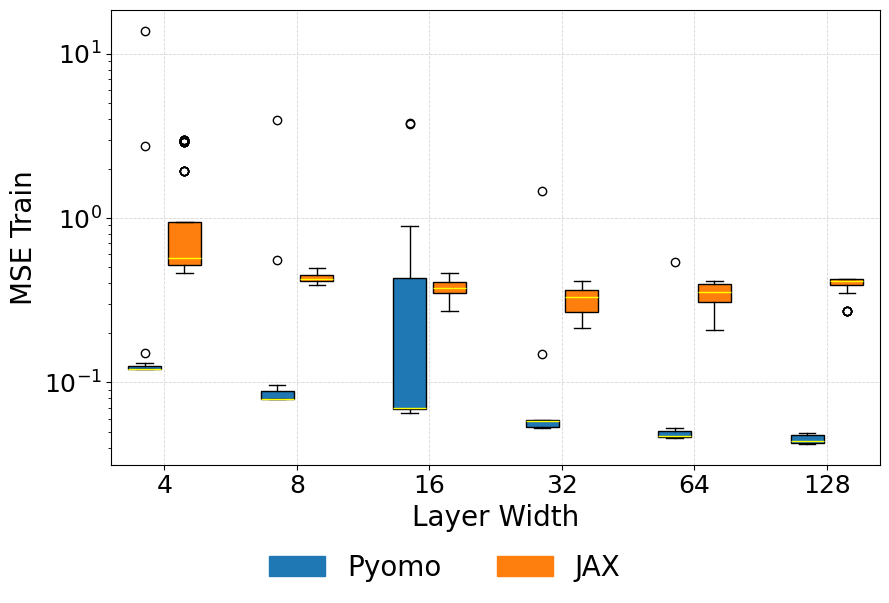

<Axes: xlabel='Layer Width', ylabel='MSE Train'>

In [15]:
Graphs.plot_boxplots_custom(pyomo_train['mse_train_coll'], jax_train['mse_train'], pyomo_train.x_labels, 
            '',     
              'MSE Train', color_labels=["Pyomo", "JAX"],
              x_label = "Layer Width",
              figsize=(9, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              y_log = True,
              line_colors="yellow"
              )

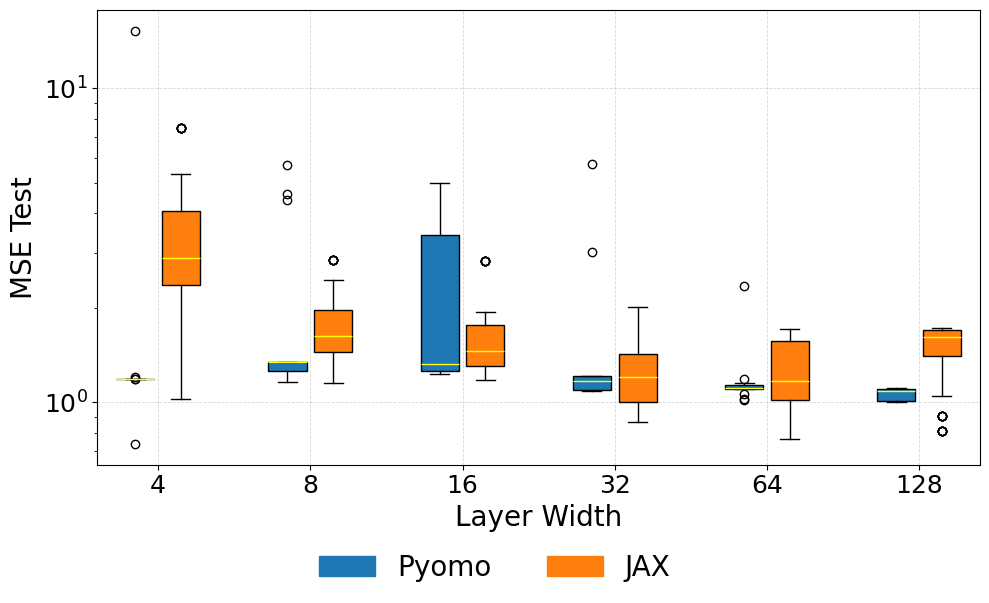

<Axes: xlabel='Layer Width', ylabel='MSE Test'>

In [16]:
Graphs.plot_boxplots_custom(pyomo_test['mse_test_coll'], jax_test['mse_test'], pyomo_train.x_labels, 
            '',     
              'MSE Test', color_labels=["Pyomo", "JAX"],
              x_label = "Layer Width",
              figsize=(10, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              y_log = True,
              line_colors="yellow"
              )

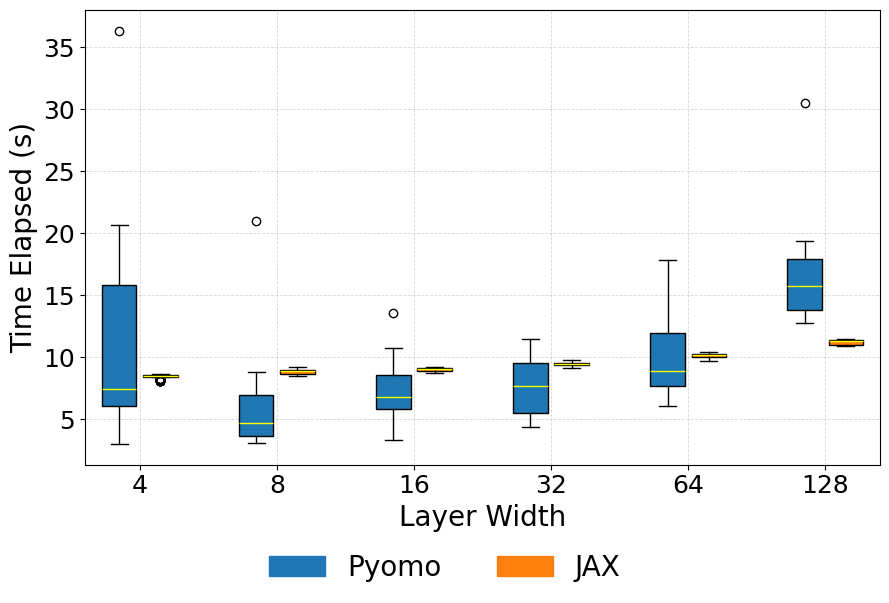

<Axes: xlabel='Layer Width', ylabel='Time Elapsed (s)'>

In [17]:
Graphs.plot_boxplots_custom(pyomo_times['time_elapsed'], jax_times['time_elapsed'], pyomo_train.x_labels, 
            '',     
              'Time Elapsed (s)', color_labels=["Pyomo", "JAX"],
              x_label = "Layer Width",
              figsize=(9, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              y_log = False,
              line_colors="yellow"
              )

In [18]:
results_reg_norm_df_0_001.head(1)

,system,reg,tol,time_elapsed,direct_model_pred,odeint_pred,odeint_pred_test,mse_train,mse_test,mse_train_coll,mse_test_coll,termination,seed,n_neurons
2,"(2, 4, 2)",0.001,0.000001,8.260239,"[[-5.993873532730279e-28, 0.000275791636625682...","[[0.0, 1.0], [0.00027554116, 1.0016934], [0.00...","[[1.9083185, -0.77511317], [1.9063884, -0.7763...",0.094955,1.518686,0.046781,1.304077,optimal,2.481537e+09,4


In [19]:
results_reg_norm_df_0_1.groupby("n_neurons")[["time_elapsed", "mse_train_coll", "mse_test_coll"]].mean()

,time_elapsed,mse_train_coll,mse_test_coll
n_neurons,,,
4,9.483666,0.545236,4.643443
8,6.511721,0.781207,4.996838
16,8.805553,0.380808,3.160387
32,10.800281,0.378617,2.645978
64,13.586469,0.352672,1.643204
96,14.687530,0.344733,1.394508
128,28.636518,0.345422,1.440131


In [20]:
results_reg_norm_df_0_01.groupby("n_neurons")[["time_elapsed", "mse_train_coll", "mse_test_coll"]].mean()

,time_elapsed,mse_train_coll,mse_test_coll
n_neurons,,,
4,11.676472,1.211259,2.094671
8,6.170084,0.370533,2.010704
16,7.301513,0.715923,2.297801
32,7.622065,0.155442,1.577029
64,10.202438,0.080536,1.189920
96,11.880233,0.061796,1.267933
128,16.675970,0.044865,1.061844


In [21]:
results_reg_norm_df_0_01[results_reg_norm_df_0_01["n_neurons"] == 16]

,system,reg,tol,time_elapsed,direct_model_pred,odeint_pred,odeint_pred_test,mse_train,mse_test,mse_train_coll,mse_test_coll,termination,seed,n_neurons
7,"(2, 16, 2)",0.01,0.000001,7.670741,"[[0.0, 0.0007201675888069728, 0.00389270666431...","[[0.0, 1.0], [0.0007345992, 1.0013641], [0.003...","[[1.9083185, -0.77511317], [1.9062798, -0.7760...",0.378903,4.034461,0.219994,3.780575,optimal,2.481537e+09,16
7,"(2, 16, 2)",0.01,0.000001,10.732163,"[[0.0, 0.001078347728006437, 0.005742581959193...","[[0.0, 1.0], [0.0010887241, 1.0014619], [0.005...","[[1.9083185, -0.77511317], [1.9063369, -0.7763...",144.848923,232.296753,3.806128,4.374390,optimal,2.602659e+09,16
7,"(2, 16, 2)",0.01,0.000001,8.870296,"[[3.6102375662598073e-16, 0.000390120304561185...","[[0.0, 1.0], [0.00039006787, 1.0012044], [0.00...","[[1.9083185, -0.77511317], [1.9066128, -0.7771...",0.069777,1.240351,0.068583,1.258773,optimal,2.615588e+09,16
7,"(2, 16, 2)",0.01,0.000001,3.317905,"[[0.0, 0.00031625171785154636, 0.0016775878423...","[[0.0, 1.0], [0.00031651132, 1.0011864], [0.00...","[[1.9083185, -0.77511317], [1.9067521, -0.7773...",0.063791,1.466947,0.064681,1.379532,optimal,2.897333e+09,16
7,"(2, 16, 2)",0.01,0.000001,13.602495,"[[5.0427224209786464e-17, 0.001104768600494298...","[[0.0, 1.0], [0.0010833859, 1.0014714], [0.005...","[[1.9083185, -0.77511317], [1.9062452, -0.7759...",82.146919,136.488327,3.712626,4.290672,optimal,3.028133e+09,16
7,"(2, 16, 2)",0.01,0.000001,6.893666,"[[2.2057375801013112e-16, 0.000422836078367243...","[[0.0, 1.0], [0.00042278916, 1.001182], [0.002...","[[1.9083185, -0.77511317], [1.9064946, -0.7770...",0.069289,1.160642,0.069596,1.231436,optimal,3.269951e+09,16
7,"(2, 16, 2)",0.01,0.000001,9.191291,"[[0.0, 0.0003875817958880627, 0.00205182619798...","[[0.0, 1.0], [0.00038754943, 1.0011964], [0.00...","[[1.9083185, -0.77511317], [1.9066399, -0.7771...",0.067504,1.204818,0.068402,1.262714,optimal,3.371381e+07,16
7,"(2, 16, 2)",0.01,0.000001,5.242665,"[[0.0, 0.0003875920732465942, 0.00205188006022...","[[0.0, 1.0], [0.0003875597, 1.0011964], [0.002...","[[1.9083185, -0.77511317], [1.9066399, -0.7771...",0.068496,1.218570,0.068404,1.262740,optimal,3.488423e+09,16
7,"(2, 16, 2)",0.01,0.000001,6.618572,"[[0.0, 0.0007502937199438348, 0.00406885763344...","[[0.0, 1.0], [0.0007672963, 1.0013741], [0.004...","[[1.9083185, -0.77511317], [1.9062039, -0.7759...",11.504553,1.835130,0.899772,2.299563,optimal,3.824353e+09,16
7,"(2, 16, 2)",0.01,0.000001,6.762368,"[[2.0561449883451223e-16, 0.000422836077814435...","[[0.0, 1.0], [0.00042278916, 1.001182], [0.002...","[[1.9083185, -0.77511317], [1.9064946, -0.7770...",0.069289,1.160642,0.069596,1.231436,optimal,3.952110e+09,16


In [22]:
results_reg_norm_df_0_001.groupby("n_neurons")[["time_elapsed", "mse_train_coll", "mse_test_coll"]].mean()

,time_elapsed,mse_train_coll,mse_test_coll
n_neurons,,,
4,17.778631,0.321086,1.594560
8,22.771183,0.163799,3.822822
16,6.454191,1.014374,2.401157
32,8.750009,0.085972,1.593987
64,16.229542,0.183350,1.344232
96,15.944100,0.208503,1.206214
128,23.676455,0.068856,1.750896


In [23]:
pyomo_train = Results.prep_for_boxplots(results_reg_norm_df_0_1,  'n_neurons',  'mse_train_coll')
pyomo_test = Results.prep_for_boxplots(results_reg_norm_df_0_1,  'n_neurons',  'mse_test_coll')
pyomo_times = Results.prep_for_boxplots(results_reg_norm_df_0_1,  'n_neurons',  'time_elapsed')

pyomo_01_train = Results.prep_for_boxplots(results_reg_norm_df_0_01,  'n_neurons',  'mse_train_coll')
pyomo_01_test = Results.prep_for_boxplots(results_reg_norm_df_0_01,  'n_neurons',  'mse_test_coll')
pyomo_01_times = Results.prep_for_boxplots(results_reg_norm_df_0_01,  'n_neurons',  'time_elapsed')

pyomo_001_train = Results.prep_for_boxplots(results_reg_norm_df_0_001,  'n_neurons',  'mse_train_coll')
pyomo_001_test = Results.prep_for_boxplots(results_reg_norm_df_0_001,  'n_neurons',  'mse_test_coll')
pyomo_001_times = Results.prep_for_boxplots(results_reg_norm_df_0_001,  'n_neurons',  'time_elapsed')

In [24]:
# Graphs.plot_lines_ci_from_lists(
#     pyomo_test['mse_test_coll'], pyomo_001_test['mse_test_coll'],
#     pyomo_train.x_labels,
#     title="",
#     ylabel="MSE Train",
#     color_labels=("Pyomo", "Jax"),
#     x_label="λ",
#     figsize=(10, 6),
#     label_fontsize=20,
#     tick_fontsize=18,
#     legend_fontsize=20,
#     title_fontsize=20,
#     legend_bbox_y=-0.02,
#     legend_ncol=2,
#     ci=(20, 80),
#     alpha_band=0.2,
#     line_width=1.25,
# )

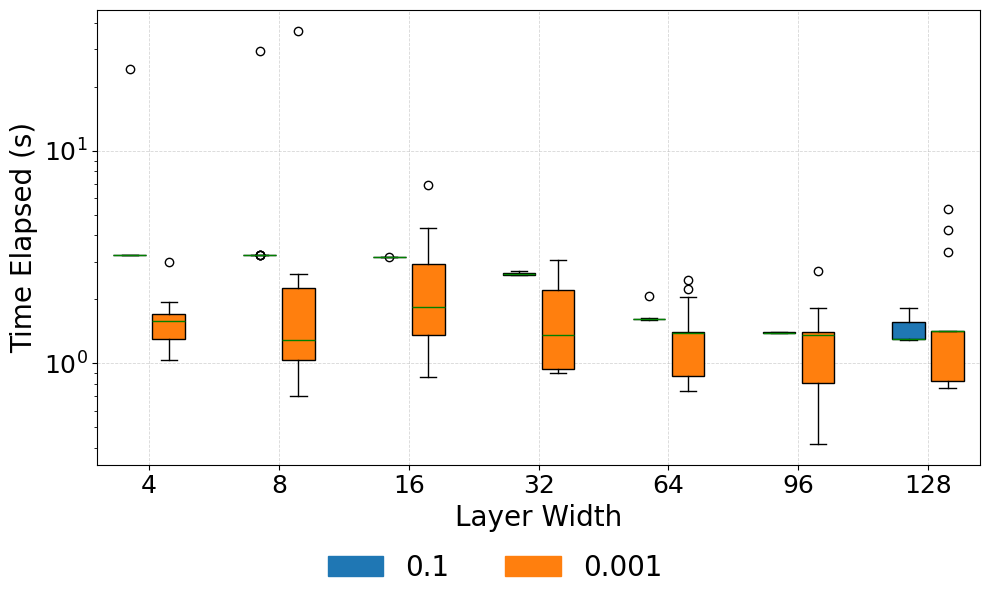

<Axes: xlabel='Layer Width', ylabel='Time Elapsed (s)'>

In [25]:
Graphs.plot_boxplots_custom(pyomo_test['mse_test_coll'], pyomo_001_test['mse_test_coll'], pyomo_train.x_labels, 
            '',     
              'Time Elapsed (s)', color_labels=["0.1", "0.001"],
              x_label = "Layer Width",
              figsize=(10, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              y_log = True
              )

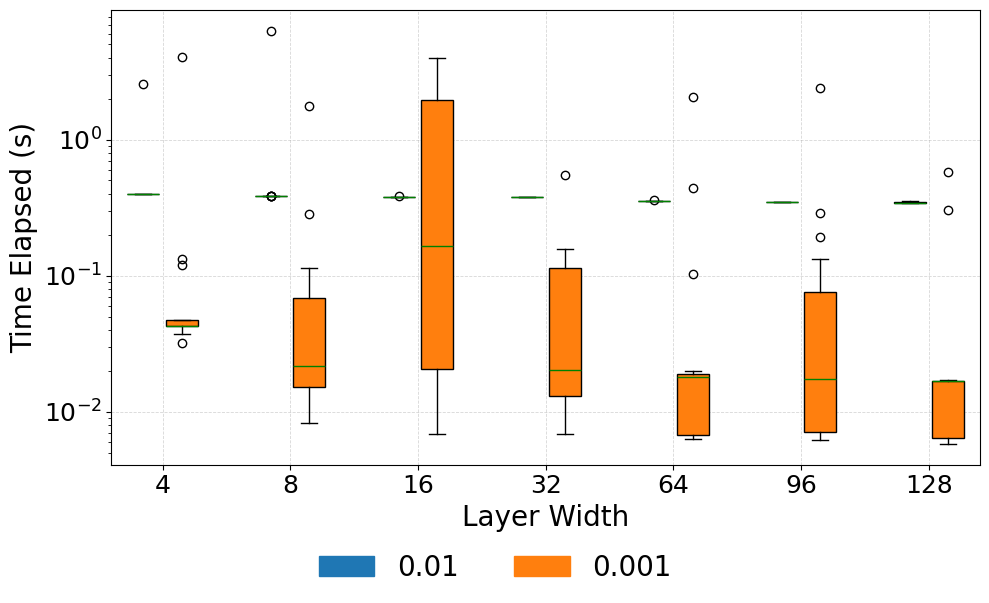

<Axes: xlabel='Layer Width', ylabel='Time Elapsed (s)'>

In [26]:
Graphs.plot_boxplots_custom(pyomo_train['mse_train_coll'], pyomo_001_train['mse_train_coll'], pyomo_train.x_labels, 
            '',     
              'Time Elapsed (s)', color_labels=["0.01", "0.001"],
              x_label = "Layer Width",
              figsize=(10, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              y_log = True
              )

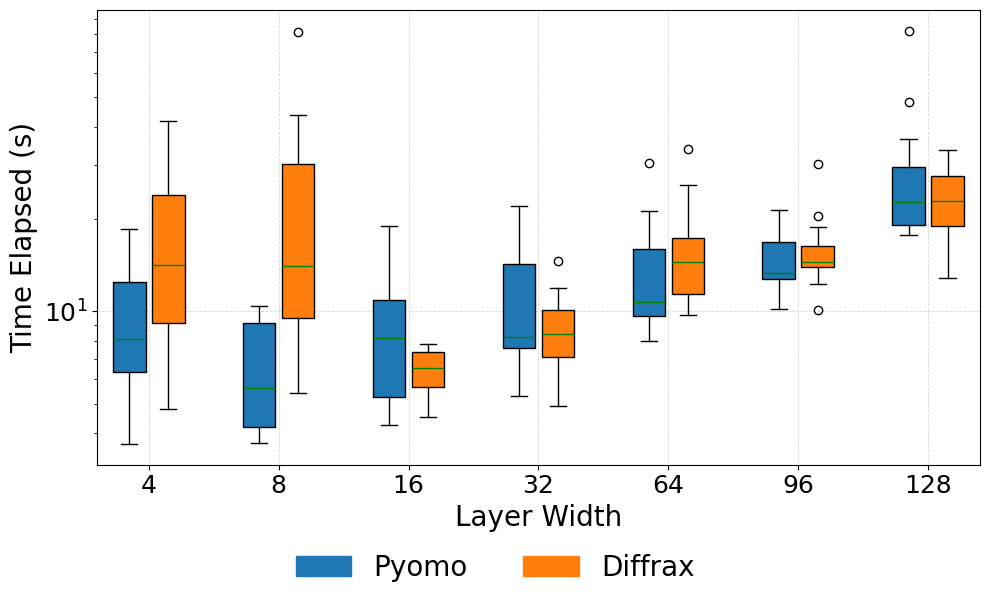

<Axes: xlabel='Layer Width', ylabel='Time Elapsed (s)'>

In [27]:
Graphs.plot_boxplots_custom(pyomo_times['time_elapsed'], pyomo_001_times['time_elapsed'], pyomo_train.x_labels, 
            '',     
              'Time Elapsed (s)', color_labels=["Pyomo", "Diffrax"],
              x_label = "Layer Width",
              figsize=(10, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              y_log = True
              )